# 2 Embdeding


## 2.1 绝对位置编码（Absolute Positional Encoding, APE）

### 2.1.1 正弦位置编码（Sinusoidal PE）

在《Attention Is All You Need》中，提出了一种基于三角函数的固定位置编码。其核心思想是利用不同频率的正弦和余弦波来为每个位置生成一个唯一的指纹（Fingerprint）。

对于位置 $pos$ 和维度 $i$，其编码公式为：

$$ \text{PE}{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right) $$

$$\text{PE}{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right) $$

其中，
- pos表示 token 在序列中的位置，取值范围为[0, 1, 2, ..., seq_len -1]；
- i表示embedding的维度索引，范围为$[0, 1, ..., d_{model}/2 - 1]$，

i的所有取值总共有$d_{model}/2$个，每一个都分别通过施加sin或cos变换来对应某个token的embedding不同位置的偶数维与奇数维。

为了便于理解，这里来举个实际的例子来演示正余弦位置编码的工作原理。

假设$d_{model}$=8，token序列长度seq_len=120，现在需要计算序列中第2个位置（即`pos`=2）的token对应的位置编码，套公式：

计算每个维度的缩放因子：(因为编码公式是计算 2i/2i+1，所以i只需要从0-3取值)
| i | 维度 (2i / 2i+1) | $\text{div\_term}_i = 10000^{2i/d_{\text{model}}}$ |
|---|------------------|------------------------------------|
| 0 | 0 / 1            | $10000^{0} = 1$                    |
| 1 | 2 / 3            | $10000^{0.25} \approx 10$          |
| 2 | 4 / 5            | $10000^{0.5} = 100$                |
| 3 | 6 / 7            | $10000^{0.75} \approx 1000$        |

带入公式计算 PE：

$$
\begin{aligned}
\text{PE}(2, 0) &= \sin(2/1) = \sin(2.0) \approx 0.9093 \\
\text{PE}(2, 1) &= \cos(2/1) = \cos(2.0) \approx -0.4161 \\
\text{PE}(2, 2) &= \sin(2/10) = \sin(0.2) \approx 0.1987 \\
\text{PE}(2, 3) &= \cos(2/10) = \cos(0.2) \approx 0.9801 \\
\text{PE}(2, 4) &= \sin(2/100) = \sin(0.02) \approx 0.0200 \\
\text{PE}(2, 5) &= \cos(2/100) = \cos(0.02) \approx 0.9998 \\
\text{PE}(2, 6) &= \sin(2/1000) = \sin(0.002) \approx 0.0020 \\
\text{PE}(2, 7) &= \cos(2/1000) = \cos(0.002) \approx 0.9999 \\
\end{aligned}
$$
最终位置编码向量（pos = 2）为：

[0.9093, -0.4161, 0.1987, 0.9801, 0.0200, 0.9998, 0.0020, 0.9999]


正余弦位置编码具有远程衰减的特性：对于一个序列中每个token的向量，在对每个token施加RoPE时，从序列token视角来看，每个token向量的低维元素(i较小)在相邻token之间的变化比较快，而高维(i较大)则比较慢。

**维度i增加，频率减小**

即当位置 pos 固定时，维度 i 越大，分母越大，pos 的变化对位置编码PE的影响越小，导致位置编码在高维度下（即i较大）的变化变得缓慢。即，相邻位置的编码差异变得非常小，直到这些位置的编码几乎趋于相同。

为了直观说明这一点，这里绘制在不同的固定i取值下，pos的变化趋势：

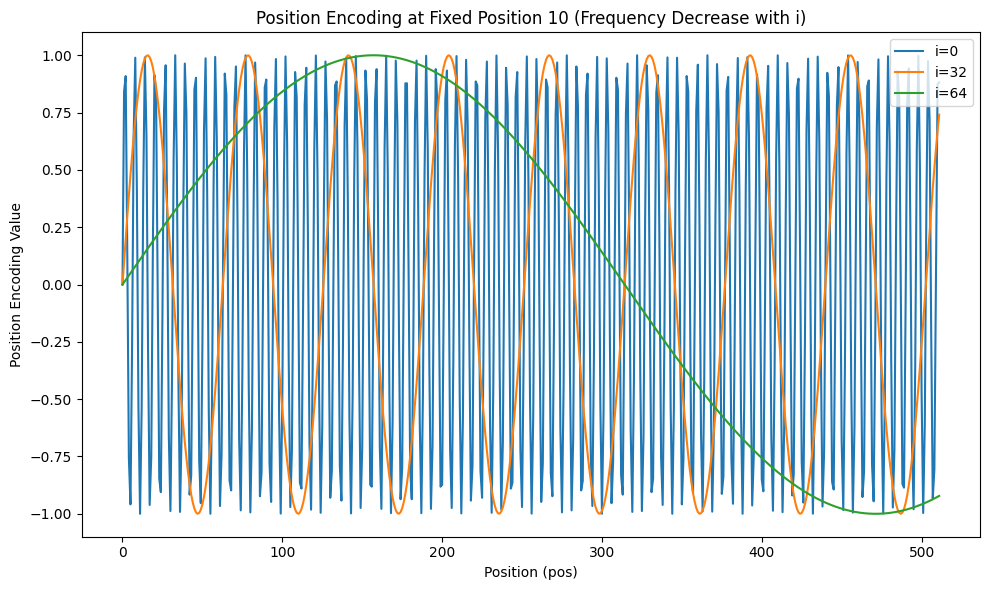

In [5]:
#%pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt

def sinusoidal_position_encoding(seq_len, d_model):
    """
    计算正余弦位置编码（Sinusoidal PE）。
    参数：
        seq_len -- 序列长度
        d_model -- 模型的维度
    返回：
        一个形状为 (seq_len, d_model) 的位置编码矩阵
    """
    position = np.arange(seq_len)[:, np.newaxis]  # (seq_len, 1)
    div_term = np.power(10000, (2 * (np.arange(d_model // 2)) / np.float32(d_model)))  # (d_model/2,)

    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position / div_term)  # 偶数维度使用正弦
    pe[:, 1::2] = np.cos(position / div_term)  # 奇数维度使用余弦

    return pe

# 参数设置
seq_len = 512  # 序列长度
d_model = 128  # 模型的维度

# 获取位置编码
pe = sinusoidal_position_encoding(seq_len, d_model)

plt.figure(figsize=(10, 6))
fixed_pos = 10  # 固定位置
for i in [0,32,64]:  # 每6个维度展示一个
    plt.plot(np.arange(seq_len), pe[:, i], label=f'i={i}')
plt.xlabel("Position (pos)")
plt.ylabel("Position Encoding Value")
plt.title(f"Position Encoding at Fixed Position {fixed_pos} (Frequency Decrease with i)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 2.1.2 Sinusoidal PE的缺陷
正余弦位置编码的最大缺陷在于，它只能提供绝对位置信息。在推理中，Attention模块计算的是Q和K的点积，而PE是直接加到embedding上，这使得模型要学习如何将绝对位置转换为相对位置信息，增加了学习负担。

同时，虽然它在理论上可以无限延伸到任意长度的序列，但在训练时只见过短序列。当推理时输入超长句子，模型之前没有见过这些位置模式，导致性能下降。

**解释以上两段话**

#### 1. 位置信息
很多语言关系更依赖两个词之间的距离，而不是各自的绝对编号。
普通位置编码直接加到词向量上：
$$x_m' = x_m + PE(m)$$
 然后生成 Query 和 Key：
$$Q_m=(x_m+PE(m))W_Q$$
$$K_n=(x_n+PE(n))W_K$$
Attention 再计算：
$$Q_mK_n^T$$
展开后会混合出很多项：
$$\text{词与词}+\text{词与位置}+\text{位置与词}+\text{位置与位置}$$
因此，相对距离 \(m-n\) 并没有直接、清晰地出现在公式里。模型需要从这些混合信息中自己学会

这种方式虽然能提供位置信息，但在注意力计算（q·k）中很容易被抵消，特别是高维度（较大的i）频率较低时，对短距离位置变化非常不敏感，导致模型在任务中“分不清细节”。

#### 2.位置信息学习
对于长序列，模型可能遇到的问题是：
- 模型遇到了训练范围之外的位置组合；
- 模型没有训练过如此长的相对距离；
- Attention 和后续网络可能依赖训练长度内的位置分布；
- 正余弦函数的一些高频维度会周期性重复，超长距离下可能产生位置混淆。

为了应对这些问题，旋转位置编码(RoPE)被提出。

RoPE继承了正余弦位置编码的远程衰减特性，但是通过将绝对位置编码转化为query和key的旋转操作，将位置差异“嵌入”到注意力机制的点积中，转而感知token间的相对位置变化。这一机制实质上以绝对编码的形式实现了相对位置感知能力，并保持了良好的可微性与推理效率，且通过周期性的旋转可以平滑外推到任意序列长度。

RoPE的目标就是在位置编码时引入m-n这一相对位置信息。

## 2.2 旋转位置编码（RoPE）

RoPE的目标，正是找到一种旋转操作，使得在不显式计算位置差m-n的情况下，位置编码自然地将“相对位置信息”融入到注意力机制中的$qk$中。换句话说，需要找到这么一种映射$g$，针对给定的两个用于计算注意力的向量$q$和$k$，以及m-n，使得
$$f(q,m)f(k,n)=g(q,k,m-n)$$

其中，$q$和$k$是长度为$d_{model}$的向量，m和n分别是对应向量中第m个和第n个pos处的元素。

RoPE的核心洞察在于：**通过绝对位置的旋转，自然诱导（Induce）出相对位置的内积性质。** 

### 2.2.1 核心数学推导
前面说过，RoPE 是将位置信息通过旋转操作直接注入到注意力机制中的 $q$ 和 $k$ 向量中。

假设：

- 模型维度：$d_{\text{model}} = 2$
- 原始向量：
  $$
  \mathbf{q} = \begin{bmatrix} 1 \\ 2 \end{bmatrix}, \quad \mathbf{k} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}
  $$
- 序列位置：设为 $\text{pos}_q = m$，$\text{pos}_k = n$
- 对应位置角频率为 $\theta = \omega \cdot \text{pos}$，其中 $\omega$ 是一个频率超参数


#### Step 1: 对 q 和 k 分别旋转
分别根据当前 $\mathbf{q}$ ， $\mathbf{k}$ 向量的所在位置$\text{pos}_q ，\text{pos}_k$计算其旋转角，并对原向量施加旋转

定义二维旋转操作为：

$$
\text{RoPE}(\mathbf{x}, \theta) = 
\begin{bmatrix}
\cos \theta & -\sin \theta \\
\sin \theta & \cos \theta
\end{bmatrix}
\cdot \mathbf{x}
$$

分别对 $\mathbf{q}$ 和 $\mathbf{k}$ 施加旋转：

- 设 $\theta_q = \omega \cdot m,\quad \theta_k = \omega \cdot n$
- 旋转后的向量为：

$$
\tilde{\mathbf{q}} = R(\theta_q)\cdot \mathbf{q}, \quad 
\tilde{\mathbf{k}} = R(\theta_k)\cdot \mathbf{k}
$$

#### Step 2: 点积操作变成了**相对位置信息的函数**

旋转后计算注意力时，执行的是：

$$
\tilde{\mathbf{q}}^\top \cdot \tilde{\mathbf{k}} = \mathbf{q}^\top R(-\theta_q) R(\theta_k) \cdot \mathbf{k}
= \mathbf{q}^\top R(\theta_k - \theta_q) \cdot \mathbf{k}
$$

即：

> **RoPE 实现了 “绝对位置编码方式得到的相对位置感知”**：注意力变成了与 $(n - m)$（即位置差）相关的点积结果。

使用RoPE时不需要再做位置编码，直接对Q，K向量的 position index 来计算 RoPE 的旋转角度
```text
token id
  ↓
Embedding
  ↓
hidden state H
  ↓
线性投影得到 Q、K、V
  ↓
只对 Q、K 应用 RoPE
  ↓
计算注意力
```

## 需要注意的是⚠️：

在 MiniMind 的 rotate_half 实现中，RoPE 是对 Q/K 最后一维里**相距 d//2 的两个分量**做二维旋转；

**不是对相邻分量做旋转**，也不是直接旋转原始 token embedding。

### 推广到多维空间

在实际的Transformer中，Embedding维度 $d$ 通常很大（如4096）。RoPE采用“分而治之”的策略，将 $d$ 维向量切分为 $d/2$ 个二维子空间。

对于第 $j$ 个子空间（即第 $2j$ 和 $2j+1$ 维），我们分配一个特定的旋转频率 $\theta_j$。

整个旋转操作可以表示为一个巨大的分块对角矩阵 $\mathbf{R}_{\Theta, m}$ 乘以向量 $\mathbf{x}$：



$$
\boldsymbol{R}_{\Theta,m}^{d_{model}} \boldsymbol{x} =
\begin{pmatrix}
\cos m\theta_0 & -\sin m\theta_0 & 0 & 0 & \cdots & 0 & 0 \\
\sin m\theta_0 & \cos m\theta_0 & 0 & 0 & \cdots & 0 & 0 \\
0 & 0 & \cos m\theta_2 & -\sin m\theta_2 & \cdots & 0 & 0 \\
0 & 0 & \sin m\theta_2 & \cos m\theta_2 & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & 0 & 0 & \cdots & \cos m\theta_{d_{model}-2} & -\sin m\theta_{d_{model}-2} \\
0 & 0 & 0 & 0 & \cdots & \sin m\theta_{d_{model}-2} & \cos m\theta_{d_{model}-2}
\end{pmatrix}
\begin{pmatrix} 
x_0 \\
x_1 \\
x_2 \\
\vdots \\
x_{d_{model}-2} \\
x_{d_{model}-1}
\end{pmatrix}
$$


其中，$\Theta=\left\{\theta_i=\omega^{-\frac{i}{d_{model}}}, i \in [0, 2, \ldots, d_{model}-2] \right\}$。

注意，公式中的m指的是pos，即序列中第m个词向量的pos=m，之所以不用pos，是为了使得公式看起来简洁。

这个高维旋转矩阵是高度稀疏的，在代码实现时，通常改写成如下方式进行替代，以减少冗余计算：

$$
\boldsymbol{R}_{\Theta,m}^{d_{model}} \boldsymbol{x} = 
\begin{pmatrix}
x_{0} \\
x_{1} \\
x_{2} \\
x_{3} \\
\vdots \\
x_{d_{model}-2} \\
x_{d_{model}-1}
\end{pmatrix} 
\otimes 
\begin{pmatrix} 
\cos m\theta_0 \\
\cos m\theta_0 \\
\cos m\theta_2 \\
\cos m\theta_2 \\
\vdots \\
\cos m\theta_{d_{model}-2} \\
\cos m\theta_{d_{model}-2}
\end{pmatrix}
+ 
\begin{pmatrix}
-x_{1} \\
x_{0} \\
-x_{3} \\
x_{2} \\
\vdots \\
-x_{d_{model}-1} \\
x_{d_{model}-2}
\end{pmatrix} 
\otimes 
\begin{pmatrix} 
\sin m\theta_0 \\
\sin m\theta_0 \\
\sin m\theta_2 \\
\sin m\theta_2 \\
\vdots \\
\sin m\theta_{d_{model}-2} \\
\sin m\theta_{d_{model}-2}
\end{pmatrix}
$$

可以看到，经过RoPE，词向量的维度不变（仍为$d_{model}$）。

**频率设定**：RoPE沿用了Vaswani正弦编码的几何级数频率设定：

$$\theta_j = \omega^{-2i/d}$$

通常 $\text{base} = 10000$。这意味着：

- **低维度（小 $i$）**：$\theta_i$ 很大，旋转速度快，负责捕捉高频的局部位置信息。
- **高维度（大 $i$）**：$\theta_i$ 很小，旋转速度极慢，负责捕捉低频的全局位置信息。

## 2.3 长上下文的挑战：内插与分辨率的博弈

虽然RoPE理论上支持无限长度，但在实际应用中，当推理长度超过训练长度（例如训练4k，推理8k）时，模型性能会崩塌（PPL爆炸）。这被称为**外推性故障（Extrapolation Failure）**。

在训练阶段，模型见过指针在 $[0, L_{train}\theta]$ 范围内的旋转组合。神经网络是一个强力的拟合器，它记住了这些旋转模式。 当推理长度达到 $L_{test} > L_{train}$ 时，旋转角度 $m\theta$ 进入了模型从未见过的数值区域（Out-of-Distribution, OOD）。这就好比你只教过模型看0点到12点的钟，突然让它看13点，虽然数学上是循环的，但在深度神经网络的非线性映射中，这种OOD输入会导致Attention Score计算出的数值异常，进而导致Softmax分布熵崩塌 。

p.s. $L_{train} = m - n$

### 2.3.1 线性内插（Position Interpolation, PI）

为了解决这个问题，Meta的研究人员（Chen et al., 2023）提出了**线性内插（Linear Interpolation）**。

假设我们要将窗口扩展 $s$ 倍（例如从4k扩展到8k，则 $s=2$）。我们将所有的位置索引 $m$ 替换为 $m/s$。

$$f(\boldsymbol{q}, m) = \boldsymbol{q} e^{i \frac{m}{s} \theta}$$

这样，原本 $0 \sim 8000$ 的范围被映射回了 $0 \sim 4000$。对于模型来说，所有的旋转角度都在它见过的训练分布内。这立刻解决了PPL爆炸的问题，微调后效果显著 。

**线性内插的代价：分辨率危机**

然而，线性内插并非没有代价。它引发了**分辨率（Resolution）缺失**的问题。

当你将位置除以 $s$ 时，相邻两个Token之间的旋转角度差 $\Delta \theta$ 也变成了原来的 $1/s$。

$$\Delta \theta_{new} = \frac{\Delta \theta_{original}}{s}$$

对于低频分量（转得慢的维度），这可能影响不大。但对于高频分量，甚至是中频分量，这种压缩会导致相邻Token在向量空间中“靠得太近”，难以区分。 这就好比你把一张高分辨率图片缩小了，虽然内容还在，但像素变得模糊了。模型在处理精细的局部关系（如相邻词的语法依赖）时，会变得迟钝。这解释了为什么线性内插在扩展倍数很大时，短文本的性能会下降 。

## 2.4 YaRN (Yet another RoPE extensioN)
为了解决线性内插的分辨率问题，社区（最初源于Reddit讨论，后被学术界证实）引入了 **神经正切核（Neural Tangent Kernel, NTK）** 理论的视角。

NTK-Aware Scaling的核心思想是：**对不同频率的维度应用不同程度的缩放。**

尽管NTK-Aware Scaling取得了巨大成功，但它在处理超长上下文（如100k+）时仍存在理论缺陷。YaRN的提出，旨在修正这些缺陷，成为目前最完善的RoPE扩展框架。它结合了**NTK-by-parts（分段NTK）**和**熵/温度调节（Temperature Scaling）** 。

### 2.4.1 什么是NTK与频谱偏差？

NTK理论揭示了深度神经网络在学习过程中的**频谱偏差（Spectral Bias）**：网络倾向于优先学习低频函数，而难以学习高频剧烈变化的函数 。 在RoPE的语境下：

- **低维度（高频 $\theta$）**：对应文本中的局部高频变化。由于波长短，它们在Embedding空间中变化剧烈。根据NTK理论，如果我们将这些高频信号进一步压缩（如PI所做的），网络将极难捕捉到这些微小的位置差异。
- **高维度（低频 $\theta$）**：对应文本中的长距离低频变化。这些信号波长很长，稍微压缩一下并不会丢失太多信息。


### 2.4.2 频率感知的非线性缩放

NTK-Aware Scaling的核心思想是：**对不同频率的维度应用不同程度的缩放。**

- **高频维度（低维）**：**不插值**（或极少插值）。因为它们负责局部位置，必须保持高分辨率，让模型能分清邻居。而且高频分量旋转得快，本来在训练中就覆盖了整个圆周，外推并不是大问题。
- **低频维度（高维）**：**强插值**。因为它们负责全局位置，旋转得慢，如果不压缩，稍微走远一点就OOD了。（**为什么容易 OOD？** 由于其波长极长（旋转极慢），在训练的 Context Window 内，这些维度往往连“半圈”都没转完（例如只覆盖了 0 到 10 度的扇区）。一旦推理长度超过训练长度，旋转角度就会进入模型从未见过的数值区域（例如 20 度），导致严重的分布外（OOD）问题。）

**实现技巧：Base Change** 我们不再直接除以 $s$，而是通过改变RoPE的基频参数 $\text{base}$（通常是10000）来实现这种非线性缩放。 令新的基频为 $b' = b \cdot s^{\frac{d}{d-2}}$。 这种变换在数学上等效于：随着维度 $d$ 的增加，缩放因子从1逐渐平滑过渡到 $s$。 结果是：低维度几乎不被压缩（保持精度），高维度被强力压缩（保证视野）。这使得模型在不微调的情况下（Zero-shot）就能获得比线性PI好得多的PPL，微调后更是如虎添翼 。

**动态NTK（Dynamic NTK）**

静态的NTK缩放有一个缺点：它固定了最大长度。如果你只输入一段很短的文本，它依然应用了缩放，导致性能略微受损。

**动态NTK**在推理时，根据当前输入的实际序列长度 $L_{current}$ 动态计算缩放倍数 $s = \max(1, L_{current} / L_{train})$。

- 当 $L_{current} \le L_{train}$ 时，不缩放，模型表现如初。
- 当 $L_{current}$ 逐渐增加时，缩放力度平滑介入。 这种方法让模型在全长度范围内都能保持最佳状态 。

### 2.4.3 YaRN (Yet another RoPE extensioN)：集大成者

#### **1 NTK-by-parts：精细化的频域手术**

YaRN的作者指出，简单的NTK Base Change虽然实现了非线性，但还不够精准。他们提出将维度明确划分为三个频段，使用 **斜坡函数（Ramp Function）** 进行混合：

1. **高频段（High Frequency）**：波长 $\lambda \ll L_{train}$。
   - 策略：**完全不插值（Extrapolation）**。保持原始旋转速度。
   - 理由：这些维度的旋转周期很短，在训练长度内已经转了无数圈，模型对各个相位的相对关系已经学得很好了，直接外推没问题。
2. **低频段（Low Frequency）**：波长 $\lambda \gg L_{train}$。
   - 策略：**线性插值（Interpolation）**。
   - 理由：这些维度在训练时只转了一点点，外推极其危险，必须压缩回已知范围。
3. **中频段**：过渡区域。

**Ramp Function 定义** ： 定义比率 $r = \frac{L_{train}}{\lambda_d}$。 设置阈值 $\alpha, \beta$。

$$\gamma(d) = \text{clamp}\left(\frac{r - \alpha}{\beta - \alpha}, 0, 1\right)$$

最终的频率 $h(\theta_d)$ 是原始频率和插值频率的加权混合：

$$h(\theta_d) = (1 - \gamma(d)) \frac{\theta_d}{s} + \gamma(d)\theta_d$$

这种分段策略彻底解决了“既要又要”的矛盾：既要保留局部的高精度（高频不插值），又要获得全局的长视野（低频插值）。



#### **2 熵理论与温度缩放（Temperature Scaling）**

这是YaRN最深刻的理论贡献。

研究发现，当我们通过插值扩展上下文时，Attention Mechanism的**分布熵（Distribution Entropy）**会发生变化。 简单来说，当序列变长，$K$ 的数量增加，点积 $QK^T$ 的分布范围会扩大（或因为距离衰减而变得平坦）。这导致Softmax后的概率分布变得比训练时更“尖锐”或更“平坦”，破坏了模型原本的注意力机制——这被称为**分布漂移（Distribution Shift）**。



**解决方案：热力学修正**

YaRN引入了一个温度系数 $t$（Temperature）来修正点积的模长。

$$\text{Attention}(Q, K) = \text{Softmax}\left(\frac{QK^T}{t\sqrt{d_k}}\right)$$

或者在代码实现中，直接将Embedding乘以 $\sqrt{1/t}$。

**$t$ 的计算公式** ： 经过大量实验，作者拟合出了一个经验公式：

$$\sqrt{\frac{1}{t}} = 0.1 \ln(s) + 1$$

其中 $s$ 是扩展倍数。

例如，当扩展倍数 $s=1$ 时，$\sqrt{1/t}=1$，无变化。当 $s$ 很大时，分母变小，相当于升高了Attention Logits的数值，使得softmax更加尖锐，从而保持模型对关键信息的聚焦能力。

P.s. 补充对**分布漂移（Distribution Shift）** 的说明

训练时，模型习惯的 Attention 可能具有这些统计特征：
```text
每个 Query 面对约 4096 个 Key
重要与不重要 Key 的分数差距约为某个范围
Softmax 最大概率通常约为某个范围
Attention 熵通常约为某个范围
```
扩展到 32768 后：
```text
每个 Query 最多面对 32768 个 Key
RoPE 插值改变了不同距离对应的 QK 分数
干扰 Key 数量增加
Softmax 最大概率和熵发生变化
这些统计规律和训练阶段不同，就称为“分布漂移”。
```
更严谨地说：
> RoPE 插值会改变相对距离到旋转角度的映射，因此可能改变各个 QK logits；上下文变长则会增加 logits 的数量，改变 Softmax 的归一化分母和极值统计。两者共同作用，使最终注意力概率的集中程度、最大值和熵可能偏离模型训练时习惯的范围。

#### **总结**
RoPE 插值负责让位置编码覆盖更长范围，解决处理长上下文时的外推故障，以及一般差值带来的分辨率问题；但是会导致分布漂移

温度缩放负责在 Key 数量增加时校准 Attention 熵、增强注意力的选择性，保持模型对关键信息的聚焦能力。解决RoPE带来的问题

In [ ]:

def precompute_freqs_cis(dim: int, end: int = int(32 * 1024), rope_base: float = 1e6, rope_scaling: dict = None):
    """
    预计算 RoPE (Rotary Position Embedding) 的频率矩阵
    
    RoPE 通过旋转矩阵将位置信息编码到 Query 和 Key 中，使模型能够理解 token 的相对位置。
    本函数预计算所有位置的 cos 和 sin 值，避免在每次前向传播时重复计算。
    
    支持 YaRN (Yet another RoPE extensioN) 外推方法，可以处理超过训练时最大长度的序列。
    
    Args:
        dim: 每个注意力头的维度（head_dim）
        end: 最大序列长度（默认 32768）
        rope_base: RoPE 的基频率参数（默认 1e6）
        rope_scaling: RoPE 外推配置字典（YaRN 方法），如果为 None 则不使用外推
        
    Returns:
        freqs_cos: 预计算的 cos 值 [end, dim]
        freqs_sin: 预计算的 sin 值 [end, dim]
    """
    # 初始化RoPE频率
    freqs, attn_factor = 1.0 / (rope_base ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim)), 1.0
    # [: (dim // 2)]表示取前 dim // 2 个元素
    # torch.arange 默认生成整数张量，.float() 将它转成浮点数，这样后面才能计算分数指数（/dim）
    if rope_scaling is not None: #就说明需要使用YaRN， YaRN: f'(i) = f(i)((1-γ) + γ/s), where γ∈[0,1] is linear ramp
        orig_max, factor, beta_fast, beta_slow, attn_factor = (
            rope_scaling.get("original_max_position_embeddings", 2048), rope_scaling.get("factor", 16),
            rope_scaling.get("beta_fast", 32.0), rope_scaling.get("beta_slow", 1.0), rope_scaling.get("attention_factor", 1.0)
        )
        # 如果推断长度大于训练长度，就进行缩放
        if end / orig_max > 1.0:
            inv_dim = lambda b: (dim * math.log(orig_max / (b * 2 * math.pi))) / (2 * math.log(rope_base))
            # inv_dim(beta) : 原始上下文旋转beta圈所对于的维度
            low, high = max(math.floor(inv_dim(beta_fast)), 0), min(math.ceil(inv_dim(beta_slow)), dim // 2 - 1)
            # 计算线性 ramp，范围在 [0, 1] 之间 
            ramp = torch.clamp((torch.arange(dim // 2, device=freqs.device).float() - low) / max(high - low, 0.001), 0, 1)
            # 计算缩放后的频率
            freqs = freqs * (1 - ramp + ramp / factor)
    # 根据end（序列长度），生成位置索引 0，1，...,end-1
    t = torch.arange(end, device=freqs.device)

    # 计算外积，得到每个位置的频率矩阵，形状为 [end, dim]
    # 计算pos*freqs，得到每个位置的旋转角度，形状为 [end, dim//2]
    freqs = torch.outer(t, freqs).float()    #每一行对应一个 token 位置，每一列对应一个 RoPE 频率
    # 将频率矩阵拆分为 cos 和 sin，并扩展到 [end, dim]，然后乘以 attn_factor
    freqs_cos = torch.cat([torch.cos(freqs), torch.cos(freqs)], dim=-1) * attn_factor
    freqs_sin = torch.cat([torch.sin(freqs), torch.sin(freqs)], dim=-1) * attn_factor
    return freqs_cos, freqs_sin


In [ ]:
# 编写RoPE的应用函数
def apply_rotary_pos_emb(q, k, cos, sin, unsqueeze_dim=1):
    # x=[a,b]，rotate_half(x) -> [-b,a]
    def rotate_half(x): 
        return torch.cat((-x[..., x.shape[-1] // 2:], x[..., : x.shape[-1] // 2]), dim=-1)
    #Q 和 K 在各自 token 位置使用对应的旋转角度
    q_embed = ((q * cos.unsqueeze(unsqueeze_dim)) + (rotate_half(q) * sin.unsqueeze(unsqueeze_dim))).to(q.dtype)
    k_embed = ((k * cos.unsqueeze(unsqueeze_dim)) + (rotate_half(k) * sin.unsqueeze(unsqueeze_dim))).to(k.dtype)
    return q_embed, k_embed